In [89]:
import os
from langchain_groq import ChatGroq
from pydantic import BaseModel, Field
from typing import Annotated, TypedDict
from dotenv import load_dotenv
from langgraph.graph import StateGraph,START,END

load_dotenv()

def keep(existing, new):
    return new if new is not None else existing


In [90]:
llm=ChatGroq(
    model="llama-3.1-8b-instant",
    api_key=os.getenv("GROQ_API_KEY"),
)

In [91]:
class Evaluation_Schema(BaseModel):
    feedback:str=Field(...,description="Detailed feedback of the essay. Do NOT include any score here. ")
    score:int=Field(...,description="Numerical score from 1 to 10 only. Return just the number, nothing else.",gt=0,lt=10)

In [92]:
structure_model=llm.with_structured_output(Evaluation_Schema)

In [93]:
class EvalState(TypedDict):
    essay: Annotated[str, keep]
    Literary_Analysis_Feedback: Annotated[str, keep]
    Literary_Analysis_Score: Annotated[int, keep]
    Rhetorical_Analysis_Feedback: Annotated[str, keep]
    Rhetorical_Analysis_Score: Annotated[int, keep]
    Critical_Analysis_Feedback: Annotated[str, keep]
    Critical_Analysis_Score: Annotated[int, keep]
    Final_Analysis_Feedback: Annotated[str, keep]
    Final_Analysis_Score: Annotated[int, keep]

In [94]:
def la(state:EvalState)->EvalState:
    essay=state["essay"]
    output=structure_model.invoke(f"Genrate the feedback for the essay based on Literary Analysis and provide the score between 0-10 for the essay: {essay}")
    return {"Literary_Analysis_Feedback":output.feedback,"Literary_Analysis_Score":output.score}
def ra(state:EvalState)->EvalState:
    essay=state["essay"]
    output=structure_model.invoke(f"Genrate the feedback for the essay based on Rhetorical Analysis and provide the score between 0-10 for the essay: {essay}")
    return {"Rhetorical_Analysis_Feedback":output.feedback,"Rhetorical_Analysis_Score":output.score}
def ca(state:EvalState)->EvalState:
    essay=state["essay"]
    output=structure_model.invoke(f"Genrate the feedback for the essay based on Critical Analysis and provide the score between 0-10 for the essay: {essay}")
    return {"Critical_Analysis_Feedback":output.feedback,"Critical_Analysis_Score":output.score}
def fa(state:EvalState)->EvalState:
    essay=state["essay"]
    output=structure_model.invoke(f"Genrate the feedback for the essay based on Final Analysis and provide the score between 0-10 for the essay: {essay}")
    return {"Final_Analysis_Feedback":output.feedback,"Final_Analysis_Score":output.score}

In [95]:
graph=StateGraph(EvalState)

In [96]:
graph.add_node("Literary_Analysis",la)
graph.add_node("Rhetorical_Analysis",ra)
graph.add_node("Critical_Analysis",ca)
graph.add_node("Final_Analysis",fa)


In [97]:
graph.add_edge(START,"Literary_Analysis")
graph.add_edge(START,"Rhetorical_Analysis")
graph.add_edge(START,"Critical_Analysis")
graph.add_edge("Literary_Analysis","Final_Analysis")
graph.add_edge("Rhetorical_Analysis","Final_Analysis")
graph.add_edge("Critical_Analysis","Final_Analysis")

In [98]:
workflow=graph.compile()

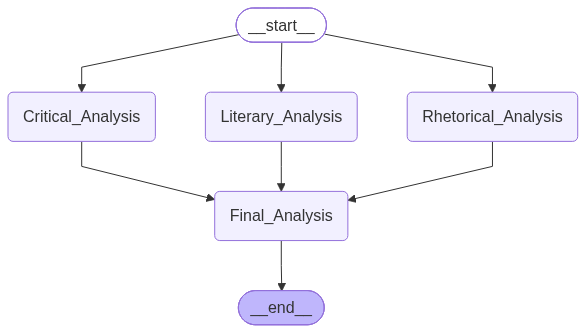

In [99]:
workflow

In [100]:
es="""India is a vast and diverse country located in South Asia. It is the seventh-largest country by land area and the most populous nation in the world. India is known for its rich history, cultural heritage, and traditions that have developed over thousands of years. Its capital is New Delhi, and it is a democratic republic with people from many different religions, languages, and cultures living together.

India has a glorious past and has made valuable contributions to mathematics, science, medicine, literature, and philosophy. The country gained independence from British rule on 15 August 1947 after a long struggle led by Mahatma Gandhi and many other freedom fighters. Today, India is one of the fastest-growing economies in the world.

The natural beauty of India is remarkable. It has the Himalayan Mountains in the north, fertile plains, deserts, forests, rivers, and a long coastline. Famous monuments such as the Taj Mahal, India Gate, and Red Fort attract millions of tourists every year. Festivals like Diwali, Holi, Eid, Christmas, and Pongal reflect the country's cultural diversity and spirit of unity.

India has made significant progress in technology, agriculture, education, healthcare, and space research. Indian scientists, engineers, and entrepreneurs have earned respect around the world. At the same time, the country faces challenges such as poverty, pollution, unemployment, and population growth. Solving these problems requires the combined efforts of the government and citizens.

In conclusion, India is a land of unity in diversity. Its rich culture, historical heritage, natural beauty, and modern achievements make it a unique and respected nation. Every citizen has a responsibility to protect the environment, respect the country's diversity, and contribute to its development. With determination, innovation, and hard work, India can continue to grow and build a brighter future for generations to come."""



In [101]:
input={"essay":es}


workflow.invoke(input)

{'essay': "India is a vast and diverse country located in South Asia. It is the seventh-largest country by land area and the most populous nation in the world. India is known for its rich history, cultural heritage, and traditions that have developed over thousands of years. Its capital is New Delhi, and it is a democratic republic with people from many different religions, languages, and cultures living together.\n\nIndia has a glorious past and has made valuable contributions to mathematics, science, medicine, literature, and philosophy. The country gained independence from British rule on 15 August 1947 after a long struggle led by Mahatma Gandhi and many other freedom fighters. Today, India is one of the fastest-growing economies in the world.\n\nThe natural beauty of India is remarkable. It has the Himalayan Mountains in the north, fertile plains, deserts, forests, rivers, and a long coastline. Famous monuments such as the Taj Mahal, India Gate, and Red Fort attract millions of to